# 03 · 리랭커 — Pairwise & SciBERT Hybrid (P5, P6, P7)

여기서부터 **학습된 랭커**다. 후보 pool을 pairwise margin ranking으로 재정렬한다.

- **P5/P6** (`scripts/pairwise_reranker.py`): 무가중 / **PRMU 가중** pairwise
- **P7** (`scripts/scibert_hybrid_ranker.py`): **SciBERT + aux 3피처 → MLP** — 이 프로젝트의 핵심 방법론

**HybridRanker 구조**: 인코더(cross-encoder)가 (문서, 후보구절)을 함께 읽어 표현을 만들고,
보조피처 `[gen_score/5, has_gen, is_present]`를 붙여 MLP(128)→스칼라 점수. PRMU 타입별 가중치로
absent(R/M/U)에 더 큰 margin을 준다.

In [1]:
import sys, json, warnings
from pathlib import Path
import pandas as pd
warnings.filterwarnings("ignore")

# repo 루트 자동 탐색 (results/ 가 있는 곳) — 노트북을 어디서 열든 동작
ROOT = Path.cwd()
while not (ROOT / "results").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))            # src.* import 가능
sys.path.insert(0, str(ROOT / "scripts"))  # 스크립트 모듈 import 가능
print("repo root:", ROOT)

repo root: C:\Users\wodlf\OneDrive\Desktop\kp20k-keyphrase-extraction


In [2]:
# 정합성 확인 — 스크립트의 실제 레시피 상수를 파일에서 그대로 읽어 표시 (드리프트 불가)
import re
src_txt = (ROOT / "scripts/scibert_hybrid_ranker.py").read_text(encoding="utf-8")
print("# scripts/scibert_hybrid_ranker.py 의 실제 레시피 상수")
for ln in src_txt.splitlines():
    if re.match(r"^(PRMU_WEIGHT|MARGIN|MAX_LEN|GEN_MISSING|N_AUX)\b", ln):
        print(ln)

# scripts/scibert_hybrid_ranker.py 의 실제 레시피 상수
PRMU_WEIGHT = {"P": 1.0, "R": 1.5, "M": 2.0, "U": 2.5}   # 노트북과 동일
MARGIN, MAX_LEN, N_AUX = 0.3, 256, 3
GEN_MISSING = -5.0


In [3]:
# HybridRanker.forward 정의를 실제 소스에서 발췌 표시
import re
m = re.search(r"class HybridRanker.*?def forward.*?\n\n", src_txt, re.S)
print(m.group(0)[:900] if m else "(패턴 못 찾음 — 파일 직접 참조)")

class HybridRanker(nn.Module):
    """SciBERT [CLS] + 보조 피처(gen_score, has_gen, is_present) → MLP 스칼라 점수."""

    def __init__(self):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(ENCODER)
        h = self.encoder.config.hidden_size
        self.head = nn.Sequential(nn.Linear(h + N_AUX, 128), nn.ReLU(),
                                  nn.Dropout(0.2), nn.Linear(128, 1))

    def forward(self, input_ids, attention_mask, aux):
        cls = self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0]
        return self.head(torch.cat([cls, aux], dim=-1)).squeeze(-1)




### P5/P6/P7 vs 비학습 최고(P2) — absent 개선이 핵심

In [4]:
grand = pd.read_csv(ROOT / "results/metrics/grand_comparison_all_models.csv")
sel = ["P2_hybrid_fusion_mmr_full","P5_pairwise_full","P6_pairwise_prmu_full","P7_scibert_hybrid_full"]
view = grand[grand.run_id.isin(sel)][["run_id","model","F1@5","present_F1@5","absent_R@10","nDCG@10"]]
view.reset_index(drop=True)

,run_id,model,F1@5,present_F1@5,absent_R@10,nDCG@10
0,P2_hybrid_fusion_mmr_full,Hybrid+MMR,0.2560,0.3420,0.0219,0.3429
1,P5_pairwise_full,Hybrid+Pairwise,0.2388,0.3109,0.0460,0.3396
2,P6_pairwise_prmu_full,Hybrid+Pairwise(PRMU-w),0.2267,0.2980,0.0494,0.3246
3,P7_scibert_hybrid_full,SciBERT Hybrid Ranker,0.2850,0.3619,0.0504,0.3975


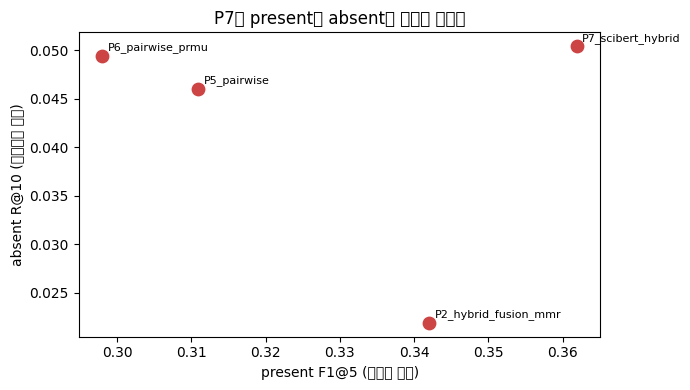

In [5]:
import matplotlib.pyplot as plt
d = grand[grand.run_id.isin(sel)].copy().sort_values("F1@5")
lab = d.run_id.str.replace("_full","",regex=False)
fig, ax = plt.subplots(figsize=(7,4))
ax.scatter(d["present_F1@5"], d["absent_R@10"], s=80, color="#c44")
for _, r in d.iterrows():
    ax.annotate(r["run_id"].replace("_full",""), (r["present_F1@5"], r["absent_R@10"]),
                fontsize=8, xytext=(4,4), textcoords="offset points")
ax.set_xlabel("present F1@5 (등장어 재현)"); ax.set_ylabel("absent R@10 (미등장어 회수)")
ax.set_title("P7은 present와 absent를 동시에 잡는다")
plt.tight_layout(); plt.show()

**관찰**: 비학습 P2는 present는 좋아도 absent 회수(0.022)가 약하다. PRMU 가중 pairwise(P6)는 absent를 0.049까지 올리고,
**P7은 present F1@5(0.362)와 absent R@10(0.050)을 동시에** 잡아 exact-vs-absent 트레이드오프를 깼다.
absent 개선은 인코더가 아니라 **방법론(PRMU 가중)의 성질**이다 (04에서 전 인코더 재현으로 확인).